In [1]:
from utils.models import StrongPolicyNet, FastPolicyNet, PolicyNet
from utils.utils_RuleBased import rule_based_AI, random_player
from utils.utils_PolicyNet import policy_agent
from utils.utils_DRL import onehot_encoder
from utils.coin_env import coin_game
from utils.utils_MCTS import mcts
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch

In [2]:
# 1. Fast Policy Network (Shallow Deep Learning)
fast_model = FastPolicyNet()
fast_weights = torch.load('utils/fast_coin.pt', map_location=torch.device('cpu'))
fast_model.load_state_dict(fast_weights); fast_model.eval()

# 2. Strong Policy Network (Deep Learning)
strong_model = StrongPolicyNet()
strong_weights = torch.load('utils/strong_coin.pt', map_location=torch.device('cpu'))
strong_model.load_state_dict(strong_weights); strong_model.eval()

# 3. Actor Model (Advantage Actor-Critic / Deep Reinforcement Learning)
actor_model = PolicyNet()
actor_weights = torch.load('utils/A2C_actor_coin.pt', map_location=torch.device('cpu'))
actor_model.load_state_dict(actor_weights); actor_model.eval()

# 4. Tabular Q-Table Matrix (Reinforcement Learning)
Q = np.loadtxt("utils/coin_Qs.csv", delimiter=',')

C:\Users\ezrab\AppData\Local\Temp\ipykernel_27416\483018698.py:76: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  plot_data = df.set_index("P1 \\ P2").replace("-", 0).applymap(lambda x: float(x.replace('%','')) if isinstance(x, str) else x)


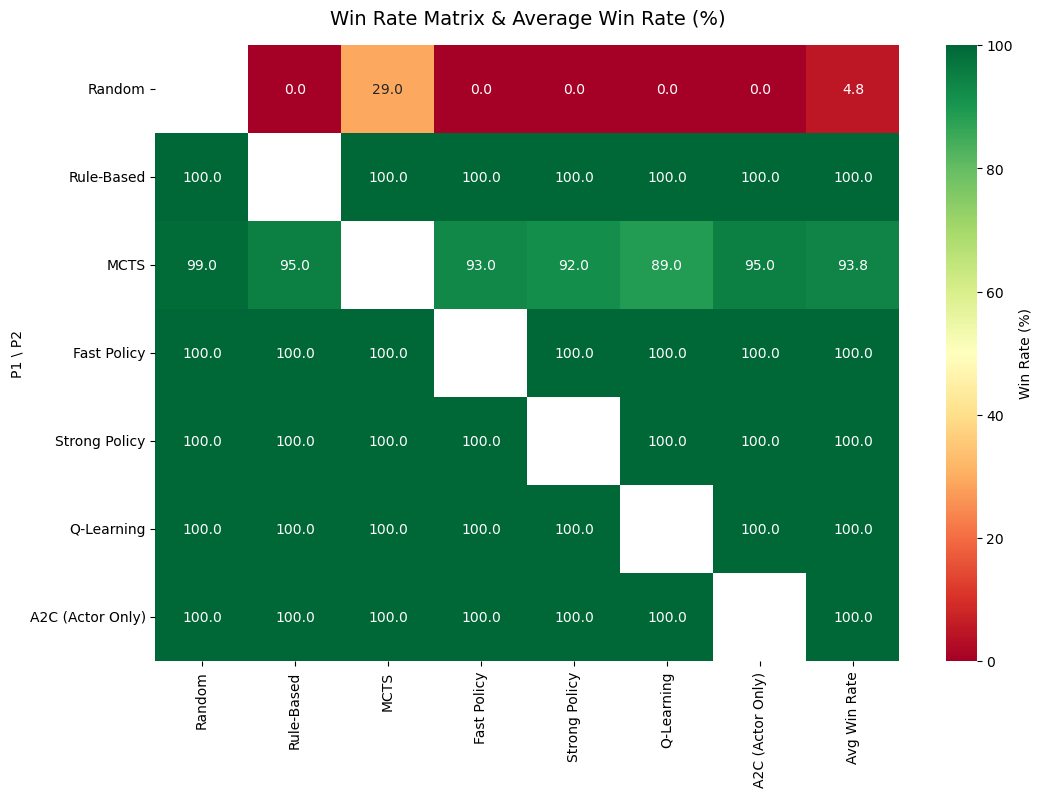

In [ ]:
env = coin_game()
models = {
    "Random":        lambda s: random_player(env),
    "Rule-Based":    lambda s: rule_based_AI(env),
    "MCTS":          lambda s: mcts(env, 1000, temperature=1.4), 
    "Fast Policy":   lambda s: policy_agent(env, fast_model, deterministic=True),
    "Strong Policy": lambda s: policy_agent(env, strong_model, deterministic=True),
    "Q-Learning":    lambda s: np.argmax(Q[s, :]),
    "A2C (Actor Only)": lambda s: np.argmax(actor_model(onehot_encoder(s)).detach().numpy().squeeze())
}

# Inisialisasi kamus metrik pencatatan optimalitas berbasis Teori Nim (posisi aman)
stats_optimalitas = {name: {"peluang": 0, "benar": 0} for name in models.keys()}
names = list(models.keys())
matrix_results = {n1: {n2: [] for n2 in names} for n1 in names}
num_games_per_match = 100

# --- SIMULASI TURNAMEN ROUND-ROBIN ANTAR AGEN AI ---
for p1_name in names:
    for p2_name in names:
        if p1_name == p2_name: continue  # Skip pertandingan melawan diri sendiri
        for _ in range(num_games_per_match):
            state = env.reset()
            while True:
                # --- GILIRAN PLAYER 1 ---
                action = models[p1_name](state)
                curr_state = state
                is_idx_0 = p1_name in ["Q-Learning", "A2C (Actor Only)"]
                act_val = action + 1 if is_idx_0 else action
                
                if curr_state % 4 != 1:
                    stats_optimalitas[p1_name]["peluang"] += 1
                    if act_val == (curr_state - 1) % 4: stats_optimalitas[p1_name]["benar"] += 1
                        
                state, reward, done, _ = env.step(act_val)
                if done:
                    matrix_results[p1_name][p2_name].append(1 if reward == 1 else -1); break

                # --- GILIRAN PLAYER 2 ---
                action = models[p2_name](state)
                curr_state = state
                is_idx_0 = p2_name in ["Q-Learning", "A2C (Actor Only)"]
                act_val = action + 1 if is_idx_0 else action
                
                if curr_state % 4 != 1:
                    stats_optimalitas[p2_name]["peluang"] += 1
                    if act_val == (curr_state - 1) % 4: stats_optimalitas[p2_name]["benar"] += 1
                        
                state, reward, done, _ = env.step(act_val)
                if done:
                    matrix_results[p1_name][p2_name].append(1 if reward == 1 else -1); break

# --- TABULASI PERSENTASE KEMENANGAN (WIN RATE MATRIX) ---
final_table = []
for p1_name in names:
    row = {"P1 \\ P2": p1_name}
    total_wins = 0
    total_games = 0
    
    for p2_name in names:
        if p1_name == p2_name: 
            row[p2_name] = "-"
        else:
            res = matrix_results[p1_name][p2_name]
            win_rate = (res.count(1) / len(res)) * 100
            row[p2_name] = f"{win_rate:.1f}%"
            
            total_wins += res.count(1)
            total_games += len(res)
            
    avg_win_rate = (total_wins / total_games) * 100 if total_games > 0 else 0
    row["Avg Win Rate"] = f"{avg_win_rate:.1f}%"
    final_table.append(row)

df = pd.DataFrame(final_table)
plot_data = df.set_index("P1 \\ P2").replace("-", 0).applymap(lambda x: float(x.replace('%','')) if isinstance(x, str) else x)

# Buat matriks mask dengan ukuran yang sama persis seperti plot_data (7 baris, 8 kolom)
mask = np.zeros_like(plot_data, dtype=bool)

# Kita isi True (kosongkan) HANYA untuk baris i dan kolom i (diagonal model 7x7)
for i in range(len(names)):
    mask[i, i] = True

plt.figure(figsize=(12, 8))

sns.heatmap(plot_data, annot=True, cmap="RdYlGn", fmt=".1f", mask=mask, cbar_kws={'label': 'Win Rate (%)'})
plt.title("Win Rate Matrix & Average Win Rate (%)", fontsize=14, pad=15)

plt.savefig("utils/win_rate_matrix.png", dpi=300, bbox_inches='tight'); plt.show()

In [ ]:
# 1. Hitung skor dan simpan ke dalam list berupa dictionary (agar mudah diubah ke DataFrame)
skor_data = []
for nama_model, data in stats_optimalitas.items():
    if data["peluang"] > 0:
        skor_akhir = (data["benar"] / data["peluang"]) * 100
        skor_data.append({
            "Model": nama_model, 
            "Total Langkah": data["peluang"],
            "Langkah Optimal": data["benar"],
            "Optimality Score": f"{skor_akhir:.2f}%"
        })

# 2. Ubah ke dalam DataFrame Pandas
df_optimalitas = pd.DataFrame(skor_data)

# 3. Cetak hasilnya dalam bentuk tabel teks formal
print("================ TABEL SKOR OPTIMALITAS LANGKAH ================")
print(df_optimalitas.to_string(index=False))
print("================================================================")

================ TABEL SKOR OPTIMALITAS LANGKAH ================
           Model  Total Langkah  Langkah Optimal Optimality Score
          Random           1339              451           33.68%
      Rule-Based           5488             5488          100.00%
            MCTS           5253             4899           93.26%
     Fast Policy           5502             5502          100.00%
   Strong Policy           5497             5497          100.00%
      Q-Learning           5529             5529          100.00%
A2C (Actor Only)           5475             5475          100.00%
